# GSplat Video Compression — Multi-Frame Delta Encoding

Compress a sequence of frames using Gaussian splatting:
1. **Keyframe (frame 0)**: fit from scratch with adaptive densification
2. **Delta frames (1–9)**: fine-tune from the *reconstructed* previous frame,
   then encode the deltas with codebook quantisation + codebook fine-tuning

Key design choices:
- Each delta frame starts from the **codebook-reconstructed** previous frame
  (not the unquantised fine-tune), so the decoder can exactly reproduce the chain
- Codebook stores only **D_eff=8** non-redundant delta dimensions (out of 14)
- Parameters stored in **FP16** for efficient storage
- Tracks PSNR, SSIM, and compression ratio throughout

## 1. Imports and Setup

In [1]:
# Add project root to path
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

Added /myhome/sdate to Python path


In [2]:
import sys, math, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

# ── Project path ──────────────────────────────────────────────────────────
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# ── gsplat_compress library ───────────────────────────────────────────────
from gsplat_compress import (
    VideoCompressor, FrameResult,
    TrainConfig, FinetuneConfig, CodebookConfig,
    ortho_camera, render, init_gaussians,
    keyframe_bytes, raw_frame_bytes, compression_ratio,
    sequence_storage_summary, decode_sequence,
    psnr, ssim, D_EFF, PARAMS_PER_GAUSSIAN_EFF,
    save_sequence, load_sequence,
)

# ── Data loading ──────────────────────────────────────────────────────────
from inct.dataset_slices import ProjectionSliceDataset

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
print("✅ Imports ready")

Device: cuda  |  PyTorch 2.11.0+cu130
GPU: NVIDIA A100 80GB PCIe
✅ Imports ready


## 2. Load Dataset and Extract Frames

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [6814.0000, 51523.0000]
ProjectionSliceDataset:
  Volume shape: (1080, 1280, 20)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 1,382,400
Loading 20 projections...
Volume shape: (1080, 1280, 20)
Total voxels: 27,648,000
Value range: [8867.8281, 46449.3125]

Volume shape: torch.Size([1080, 1280, 20])
Image size: 1080 × 1280
Frames to compress: 20
  Frame 0: range [0.0000, 1.0000]
  Frame 1: range [0.0000, 1.0000]
  Frame 2: range [0.0000, 1.0000]
  Frame 3: range [0.0000, 1.0000]
  Frame 4: range [0.0000, 1.0000]
  Frame 5: range [0.0000, 1.0000]
  Frame 6: range [0.0000, 1.0000]
  Frame 7: range [0.0000, 1.0000]
  Frame 8: range [0.0000, 1.0000

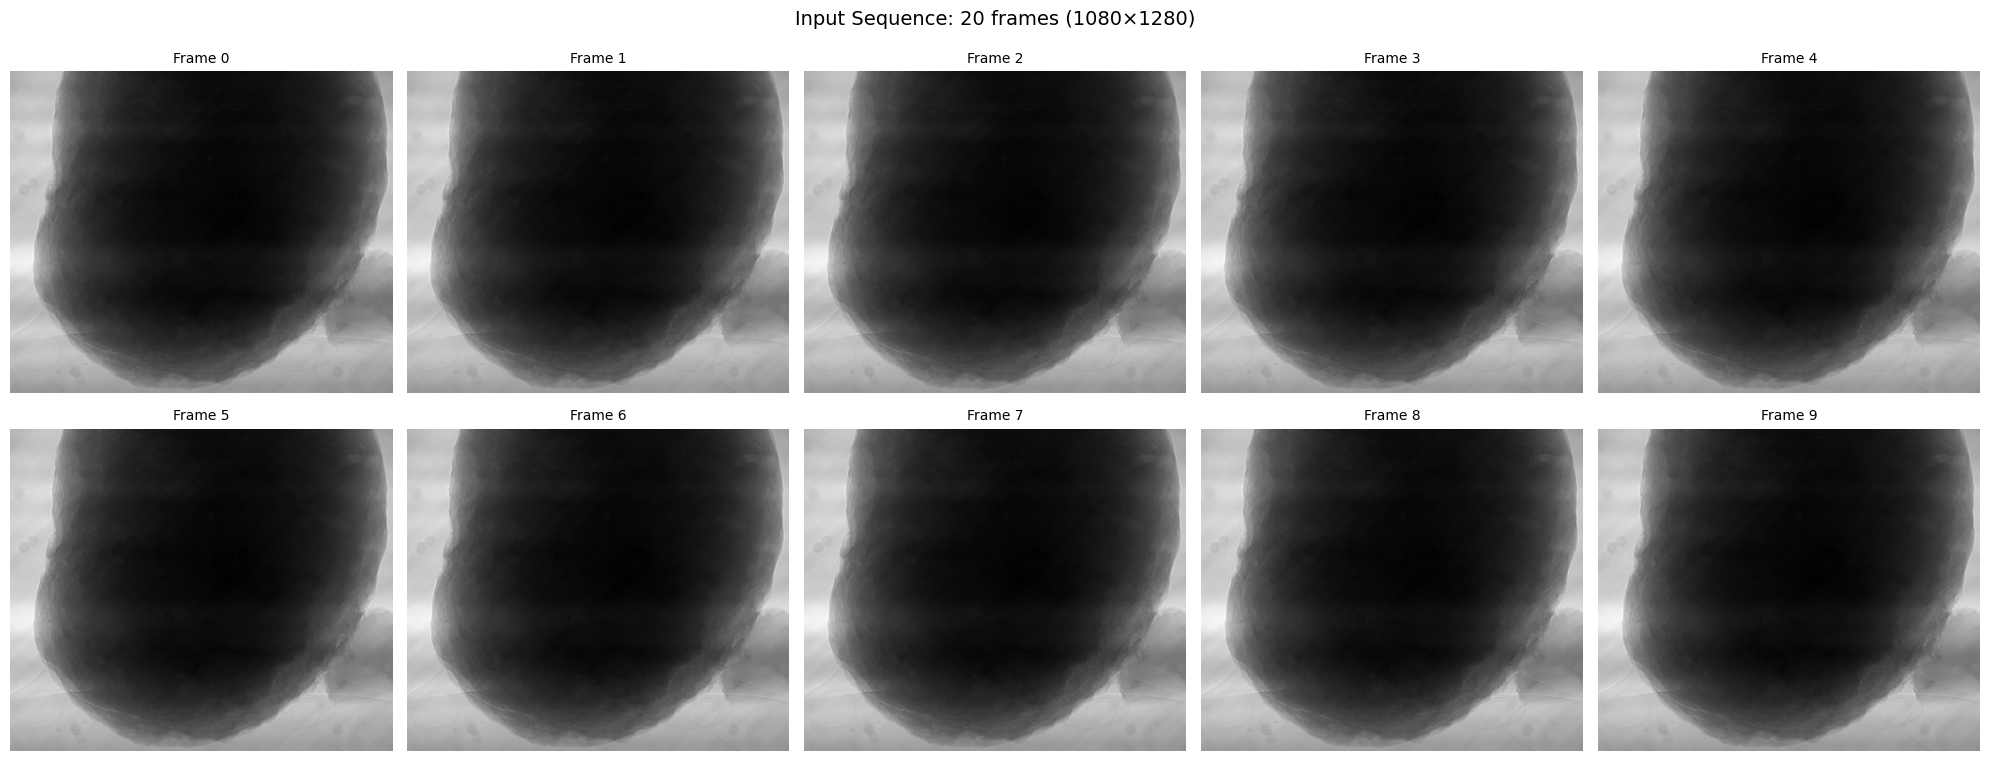

In [4]:
DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')
NUM_PROJECTIONS = 20
TARGET_SIZE      = (2560 // 2, 2160 // 2)
N_FRAMES = 20  # Number of frames to compress

dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=False,
)

volume = dataset.get_full_volume()  # (H, W, D)
H, W = volume.shape[:2]
print(f"\nVolume shape: {volume.shape}")
print(f"Image size: {H} × {W}")
print(f"Frames to compress: {N_FRAMES}")

# Extract and normalise frames
frames = []
for i in range(N_FRAMES):
    img = volume[:, :, i].clone()
    img_min, img_max = img.min(), img.max()
    img = (img - img_min) / (img_max - img_min + 1e-8)
    frames.append(img)
    print(f"  Frame {i}: range [{img.min():.4f}, {img.max():.4f}]")

# ── Show all frames ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(frames[i].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Frame {i}', fontsize=10)
    ax.axis('off')
plt.suptitle(f'Input Sequence: {N_FRAMES} frames ({H}×{W})', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Configuration

In [5]:
# ── Keyframe training config ──────────────────────────────────────────────
N_POINTS = 100_000
USE_FP16 = True

train_cfg = TrainConfig(
    num_iterations=20_000,
    use_fp16=USE_FP16,
    log_interval=500,
    lr_means=1e-3,
    lr_scales=5e-3,
    lr_quats=1e-3,
    lr_rgbs=1e-2,
    lr_opacities=5e-2,
    densify_from=2000,
    densify_interval=500,
    densify_until=15_000,
    prune_opacity_thresh=0.002,
    split_scale_thresh=20.0,
)

# ── Delta-frame fine-tuning config ────────────────────────────────────────
ft_cfg = FinetuneConfig(
    num_iterations=15_000,
    use_fp16=USE_FP16,
    log_interval=2000,
    lr_scale=0.3,
)


# ── Codebook compression config ──────────────────────────────────────────
cb_cfg = CodebookConfig(
    n_clusters=4096,
    kmeans_n_init=10,
    kmeans_max_iter=500,
    finetune_iter=2000,
    finetune_lr=5e-4,
    use_fp16=USE_FP16,
)

print("Configuration:")
print(f"  Keyframe:  {train_cfg.num_iterations} iters, {N_POINTS:,} initial Gaussians")
print(f"  Fine-tune: {ft_cfg.num_iterations} iters, lr_scale={ft_cfg.lr_scale}")
print(f"  Codebook:  K={cb_cfg.n_clusters}, {cb_cfg.finetune_iter} FT iters")
print(f"  Precision: {'FP16' if USE_FP16 else 'FP32'}")
print(f"  D_eff:     {D_EFF} (effective delta dimensions)")

Configuration:
  Keyframe:  20000 iters, 100,000 initial Gaussians
  Fine-tune: 15000 iters, lr_scale=0.3
  Codebook:  K=4096, 2000 FT iters
  Precision: FP16
  D_eff:     8 (effective delta dimensions)


## 4. Compress the Sequence

The ``VideoCompressor`` encodes frame 0 as a keyframe,
then each subsequent frame as a delta from the **reconstructed** previous frame.

$$\theta^{(t)}_{\text{rec}} = \theta^{(t-1)}_{\text{rec}} + C\left[\ell^{(t)}\right]$$

where $C$ is the fine-tuned codebook and $\ell$ are the per-Gaussian cluster labels.

In [6]:
vc = VideoCompressor(device=device, use_fp16=USE_FP16)

results = vc.compress_sequence(
    frames,
    n_points=N_POINTS,
    init_mode='uniform',
    train_cfg=train_cfg,
    ft_cfg=ft_cfg,
    cb_cfg=cb_cfg,
    verbose=True,
)

Compressing sequence: 20 frames
Training keyframe: 20000 iters, N=100,489, fp16=True


Output()

gsplat: CUDA extension has been set up successfully in 92.33 seconds.

[    0/20000]  loss=0.010678  PSNR=19.71 dB  N=100,489
[  500/20000]  loss=0.000027  PSNR=45.74 dB  N=100,489
[ 1000/20000]  loss=0.000022  PSNR=46.64 dB  N=100,489
[ 1500/20000]  loss=0.000019  PSNR=47.25 dB  N=100,489
[ 2000/20000]  loss=0.000017  PSNR=47.72 dB  N=100,489
  ↳ [densify @ 2000]  pruned=0  split=0  N=100,489
[ 2500/20000]  loss=0.000015  PSNR=48.26 dB  N=100,489
  ↳ [densify @ 2500]  pruned=0  split=0  N=100,489
[ 3000/20000]  loss=0.000014  PSNR=48.62 dB  N=100,489
  ↳ [densify @ 3000]  pruned=0  split=0  N=100,489
[ 3500/20000]  loss=0.000013  PSNR=48.90 dB  N=100,489
  ↳ [densify @ 3500]  pruned=0  split=0  N=100,489
[ 4000/20000]  loss=0.000012  PSNR=49.14 dB  N=100,489
  ↳ [densify @ 4000]  pruned=0  split=0  N=100,489
[ 4500/20000]  loss=0.000012  PSNR=49.34 dB  N=100,489
  ↳ [densify @ 4500]  pruned=0  split=0  N=100,489
[ 5000/20000]  loss=0.000011  PSNR=49.51 dB  N=100,489
  ↳ [densify @ 5000]  pruned=0  split=0  N=100,489
[ 5500/20000]  loss=0.000011  PSNR=49.

## 5. Quality & Compression Summary

In [7]:
# ── Per-frame summary table ───────────────────────────────────────────────
print(f"{'Frame':>6} {'Type':>9} {'PSNR':>8} {'SSIM':>8} {'Bytes':>12} {'CR':>8} {'Time':>7}")
print("-" * 65)
for fr in results:
    print(f"{fr.frame_idx:>6d} {fr.frame_type:>9} {fr.psnr:>8.2f} {fr.ssim:>8.4f} "
          f"{fr.compressed_bytes:>12,} {fr.compression_ratio:>8.2f}× {fr.elapsed:>6.1f}s")

# ── Overall sequence summary ───────────────────────────────────────────────
summary = vc.summary(H, W)
print(f"\n{'='*65}")
print(f"SEQUENCE SUMMARY ({summary['n_frames']} frames)")
print(f"{'='*65}")
print(f"  Total compressed : {summary['total_compressed_bytes']/1e6:.3f} MB")
print(f"  Total raw (int16): {summary['total_raw_bytes']/1e6:.3f} MB")
print(f"  Overall CR       : {summary['overall_compression_ratio']:.2f}×")
print(f"  Keyframe         : {summary['keyframe_bytes']/1e6:.3f} MB")

# Average quality
avg_psnr = np.mean([fr.psnr for fr in results])
avg_ssim = np.mean([fr.ssim for fr in results])
delta_psnrs = [fr.psnr for fr in results[1:]]
delta_ssims = [fr.ssim for fr in results[1:]]
print(f"\n  Avg PSNR (all)   : {avg_psnr:.2f} dB")
print(f"  Avg SSIM (all)   : {avg_ssim:.4f}")
if delta_psnrs:
    print(f"  Avg PSNR (delta) : {np.mean(delta_psnrs):.2f} dB")
    print(f"  Avg SSIM (delta) : {np.mean(delta_ssims):.4f}")
    print(f"  Min PSNR (delta) : {np.min(delta_psnrs):.2f} dB")
    print(f"  Max PSNR (delta) : {np.max(delta_psnrs):.2f} dB")
print(f"{'='*65}")

 Frame      Type     PSNR     SSIM        Bytes       CR    Time
-----------------------------------------------------------------
     0  keyframe    51.13   0.9927    1,808,802     1.53×  175.4s
     1     delta    49.69   0.9905      216,270    12.78×  187.4s
     2     delta    49.30   0.9898      216,270    12.78×  217.1s
     3     delta    49.13   0.9894      216,270    12.78×  198.2s
     4     delta    49.10   0.9895      216,270    12.78×  204.3s
     5     delta    48.96   0.9891      216,270    12.78×  241.7s
     6     delta    49.03   0.9893      216,270    12.78×  222.8s
     7     delta    48.97   0.9891      216,270    12.78×  225.7s
     8     delta    48.96   0.9891      216,270    12.78×  194.5s
     9     delta    48.95   0.9890      216,270    12.78×  222.4s
    10     delta    48.90   0.9889      216,270    12.78×  211.5s
    11     delta    48.91   0.9890      216,270    12.78×  206.1s
    12     delta    48.93   0.9890      216,270    12.78×  199.3s
    13     

## 6. Visualisation — Rendered Frames

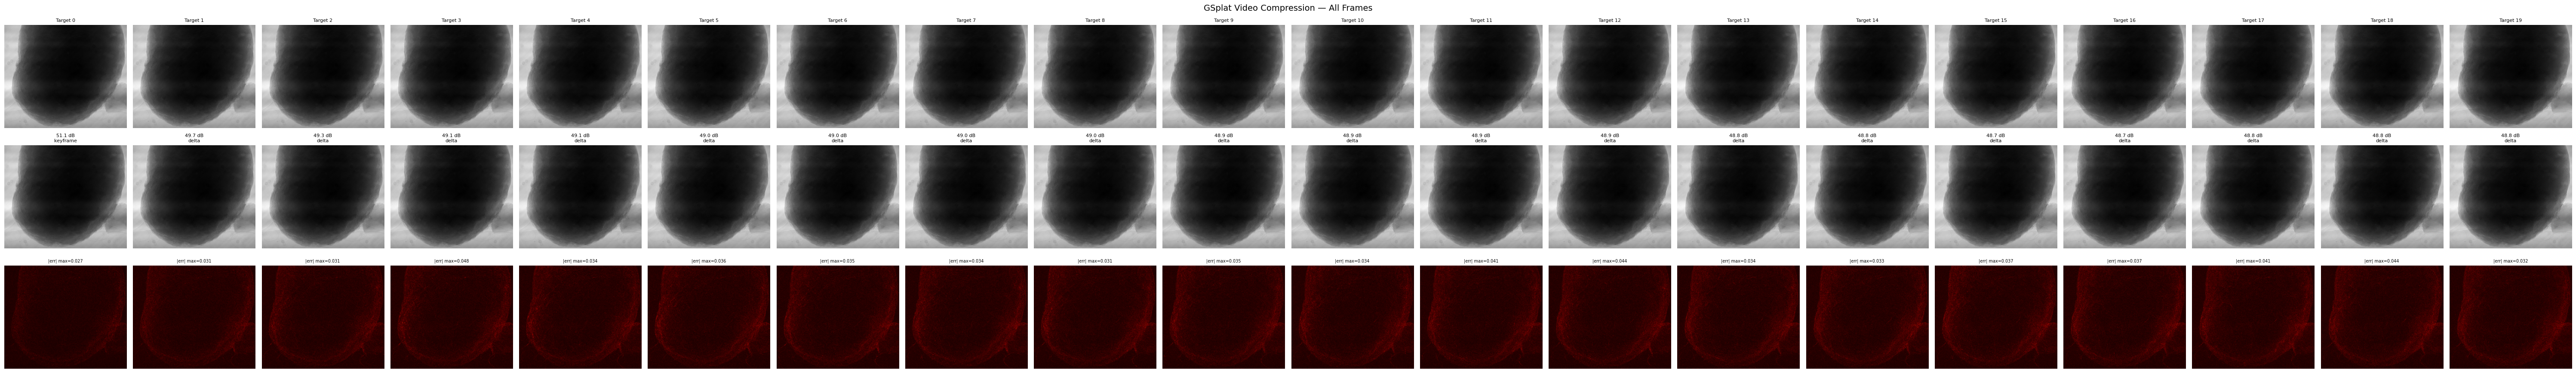

In [8]:
# ── Show all reconstructed frames alongside targets ───────────────────────
fig, axes = plt.subplots(3, N_FRAMES, figsize=(3 * N_FRAMES, 9))

for i, fr in enumerate(results):
    target_np = frames[i].cpu().numpy()
    rec_np = fr.rendered_np
    err_np = np.abs(rec_np - target_np)

    axes[0, i].imshow(target_np, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Target {i}', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(rec_np, cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'{fr.psnr:.1f} dB\n{fr.frame_type}', fontsize=8)
    axes[1, i].axis('off')

    axes[2, i].imshow(err_np, cmap='hot', vmin=0, vmax=0.05)
    axes[2, i].set_title(f'|err| max={err_np.max():.3f}', fontsize=7)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Target', fontsize=10)
axes[1, 0].set_ylabel('Reconstructed', fontsize=10)
axes[2, 0].set_ylabel('|Error|', fontsize=10)

plt.suptitle('GSplat Video Compression — All Frames', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Quality and Compression Curves

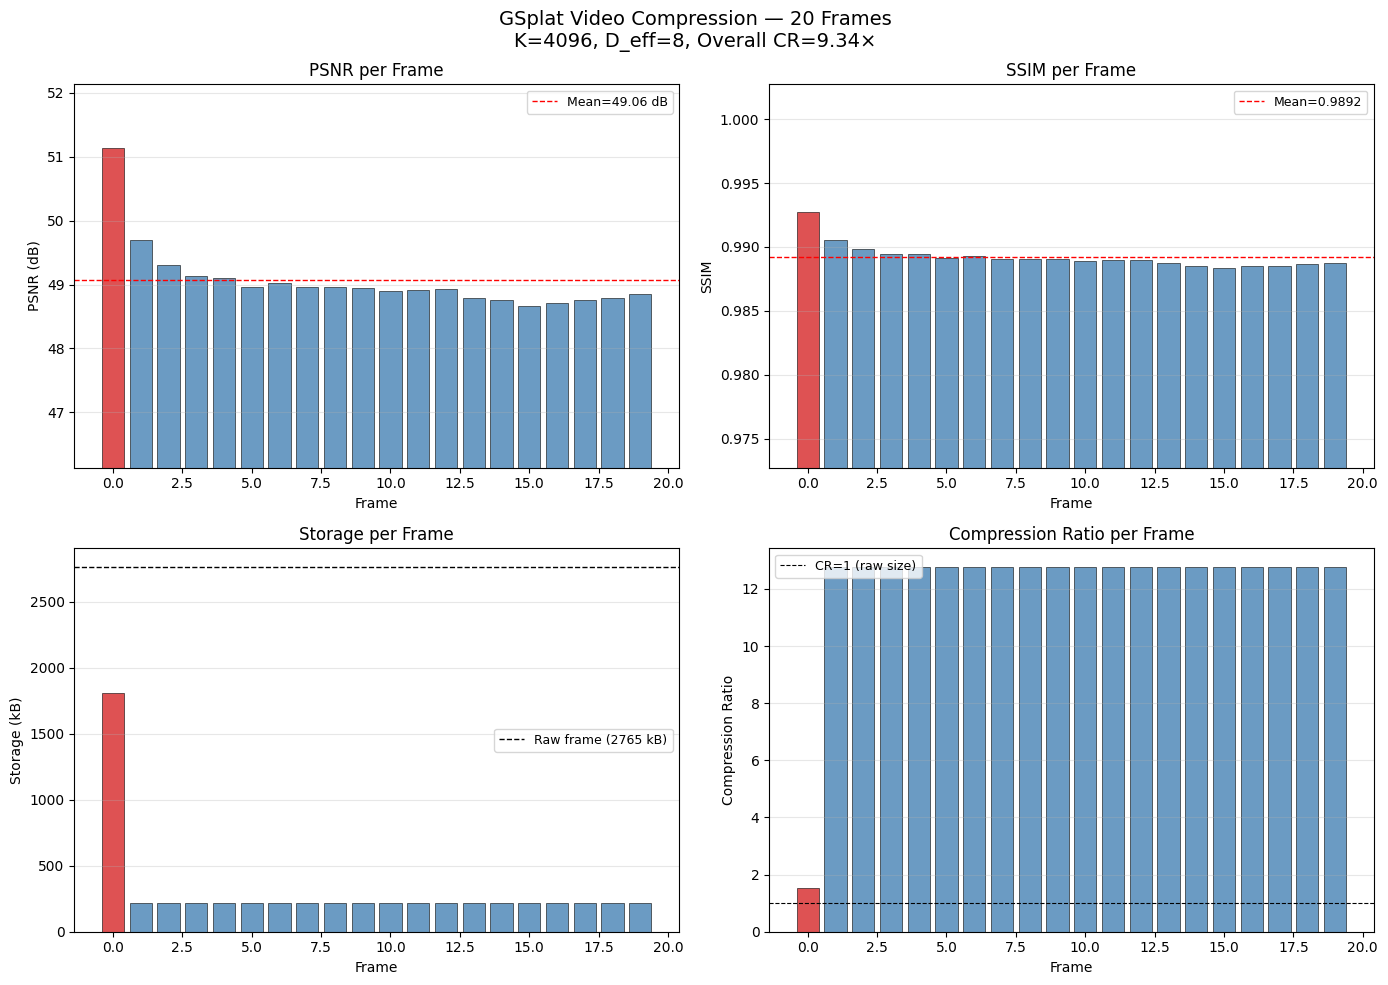

In [17]:
frame_idxs = [fr.frame_idx for fr in results]
psnrs_all  = [fr.psnr for fr in results]
ssims_all  = [fr.ssim for fr in results]
crs_all    = [fr.compression_ratio for fr in results]
bytes_all  = [fr.compressed_bytes for fr in results]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PSNR per frame
colors = ['tab:red' if i == 0 else 'steelblue' for i in frame_idxs]
axes[0, 0].bar(frame_idxs, psnrs_all, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0, 0].set_ylim(max(psnrs_all) -5, max(psnrs_all) + 1)
axes[0, 0].axhline(np.mean(psnrs_all), color='red', linestyle='--', linewidth=1,
                    label=f'Mean={np.mean(psnrs_all):.2f} dB')
axes[0, 0].set_xlabel('Frame'); axes[0, 0].set_ylabel('PSNR (dB)')
axes[0, 0].set_title('PSNR per Frame'); axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# SSIM per frame
axes[0, 1].bar(frame_idxs, ssims_all, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0, 1].set_ylim(max(ssims_all) -0.02, max(ssims_all) + 0.01)
axes[0, 1].axhline(np.mean(ssims_all), color='red', linestyle='--', linewidth=1,
                    label=f'Mean={np.mean(ssims_all):.4f}')
axes[0, 1].set_xlabel('Frame'); axes[0, 1].set_ylabel('SSIM')
axes[0, 1].set_title('SSIM per Frame'); axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Storage per frame
axes[1, 0].bar(frame_idxs, [b/1e3 for b in bytes_all], color=colors,
               alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1, 0].axhline(raw_frame_bytes(H, W)/1e3, color='black', linestyle='--',
                    linewidth=1, label=f'Raw frame ({raw_frame_bytes(H, W)/1e3:.0f} kB)')
axes[1, 0].set_xlabel('Frame'); axes[1, 0].set_ylabel('Storage (kB)')
axes[1, 0].set_title('Storage per Frame'); axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Compression ratio per frame
axes[1, 1].bar(frame_idxs, crs_all, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1, 1].axhline(1.0, color='black', linestyle='--', linewidth=0.8, label='CR=1 (raw size)')
axes[1, 1].set_xlabel('Frame'); axes[1, 1].set_ylabel('Compression Ratio')
axes[1, 1].set_title('Compression Ratio per Frame'); axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle(f'GSplat Video Compression — {N_FRAMES} Frames\n'
             f'K={cb_cfg.n_clusters}, D_eff={D_EFF}, '
             f'Overall CR={summary["overall_compression_ratio"]:.2f}×',
             fontsize=14)
plt.tight_layout()
plt.show()

## 8. Cumulative Compression Analysis

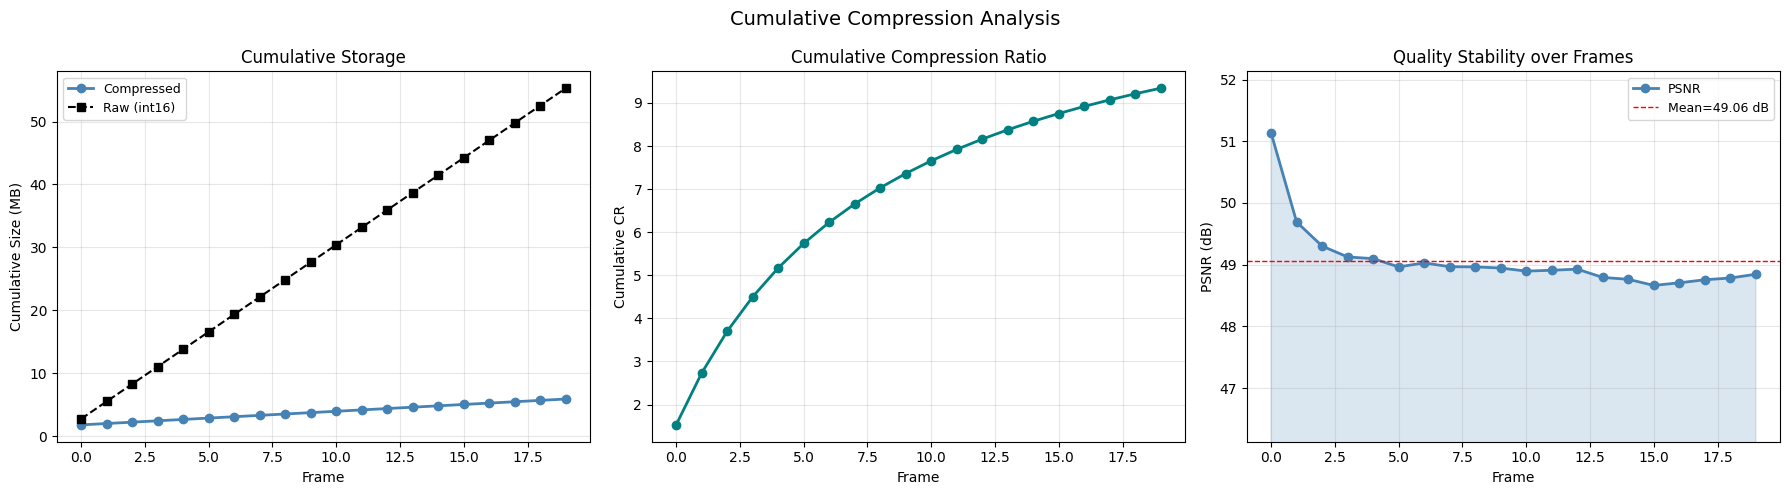

 Frames   Compressed          Raw   Cum CR
------------------------------------------
  0–0          1.809M       2.765M     1.53×
  0–1          2.025M       5.530M     2.73×
  0–2          2.241M       8.294M     3.70×
  0–3          2.458M      11.059M     4.50×
  0–4          2.674M      13.824M     5.17×
  0–5          2.890M      16.589M     5.74×
  0–6          3.106M      19.354M     6.23×
  0–7          3.323M      22.118M     6.66×
  0–8          3.539M      24.883M     7.03×
  0–9          3.755M      27.648M     7.36×
  0–10         3.972M      30.413M     7.66×
  0–11         4.188M      33.178M     7.92×
  0–12         4.404M      35.942M     8.16×
  0–13         4.620M      38.707M     8.38×
  0–14         4.837M      41.472M     8.57×
  0–15         5.053M      44.237M     8.75×
  0–16         5.269M      47.002M     8.92×
  0–17         5.485M      49.766M     9.07×
  0–18         5.702M      52.531M     9.21×
  0–19         5.918M      55.296M     9.34×


In [13]:
# ── Cumulative bytes and compression ratio over frames ─────────────────────
cum_compressed = np.cumsum(bytes_all)
cum_raw = np.cumsum([raw_frame_bytes(H, W)] * N_FRAMES)
cum_cr = cum_raw / cum_compressed

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cumulative size
axes[0].plot(frame_idxs, cum_compressed / 1e6, 'o-', color='steelblue', linewidth=2,
             label='Compressed')
axes[0].plot(frame_idxs, cum_raw / 1e6, 's--', color='black', linewidth=1.5,
             label='Raw (int16)')
axes[0].set_xlabel('Frame'); axes[0].set_ylabel('Cumulative Size (MB)')
axes[0].set_title('Cumulative Storage'); axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Cumulative CR
axes[1].plot(frame_idxs, cum_cr, 'o-', color='teal', linewidth=2)
axes[1].set_xlabel('Frame'); axes[1].set_ylabel('Cumulative CR')
axes[1].set_title('Cumulative Compression Ratio'); axes[1].grid(True, alpha=0.3)

# PSNR trend
axes[2].plot(frame_idxs, psnrs_all, 'o-', color='steelblue', linewidth=2, label='PSNR')
axes[2].set_ylim(max(psnrs_all) -5, max(psnrs_all) + 1)
axes[2].fill_between(frame_idxs, psnrs_all, alpha=0.2, color='steelblue')
axes[2].axhline(np.mean(psnrs_all), color='red', linestyle='--', linewidth=1,
                label=f'Mean={np.mean(psnrs_all):.2f} dB')
axes[2].set_xlabel('Frame'); axes[2].set_ylabel('PSNR (dB)')
axes[2].set_title('Quality Stability over Frames'); axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Cumulative Compression Analysis', fontsize=14)
plt.tight_layout()
plt.show()

# ── Print cumulative table ────────────────────────────────────────────────
print(f"{'Frames':>7} {'Compressed':>12} {'Raw':>12} {'Cum CR':>8}")
print("-" * 42)
for i in range(N_FRAMES):
    print(f"  0–{i:<4d} {cum_compressed[i]/1e6:>11.3f}M {cum_raw[i]/1e6:>11.3f}M "
          f"{cum_cr[i]:>8.2f}×")

## 9. Save Compressed Sequence

In [ ]:
# ── Save the compressed sequence ──────────────────────────────────────────
save_path = vc.save(
    project_root / 'checkpoints' / f'gsplat_video_{N_FRAMES}frames.pt',
    metadata={
        'n_frames': N_FRAMES,
        'H': H, 'W': W,
        'n_points': N_POINTS,
        'codebook_K': cb_cfg.n_clusters,
        'avg_psnr': float(np.mean([fr.psnr for fr in results])),
        'avg_ssim': float(np.mean([fr.ssim for fr in results])),
        'overall_cr': summary['overall_compression_ratio'],
    },
)

file_size_mb = save_path.stat().st_size / 1e6
print(f"Saved to: {save_path}")
print(f"File size on disk: {file_size_mb:.3f} MB")
print(f"Raw equivalent:    {N_FRAMES * raw_frame_bytes(H, W) / 1e6:.3f} MB")
print(f"Disk CR:           {N_FRAMES * raw_frame_bytes(H, W) / save_path.stat().st_size:.2f}×")

Saved to: /myhome/sdate/checkpoints/gsplat_video_10frames.pt
File size on disk: 6.894 MB
Raw equivalent:    55.296 MB
Disk CR:           8.02×


## 10. Verify: Load and Decode

Loaded 20 frames from gsplat_video_10frames.pt
Metadata: {'n_frames': 20, 'H': 1080, 'W': 1280, 'n_points': 100000, 'codebook_K': 4096, 'avg_psnr': 49.063840178047236, 'avg_ssim': 0.9892239369738614, 'overall_cr': 9.343804558754647}

 Frame     PSNR     SSIM
-------------------------
     0    48.08   0.9896
     1    47.37   0.9875
     2    47.17   0.9869
     3    47.10   0.9866
     4    47.16   0.9867
     5    47.13   0.9865
     6    47.17   0.9866
     7    47.15   0.9865
     8    47.19   0.9865
     9    47.20   0.9865
    10    47.20   0.9864
    11    47.20   0.9865
    12    47.18   0.9865
    13    47.07   0.9862
    14    47.04   0.9861
    15    46.97   0.9859
    16    47.04   0.9861
    17    47.13   0.9862
    18    47.17   0.9863
    19    47.25   0.9864


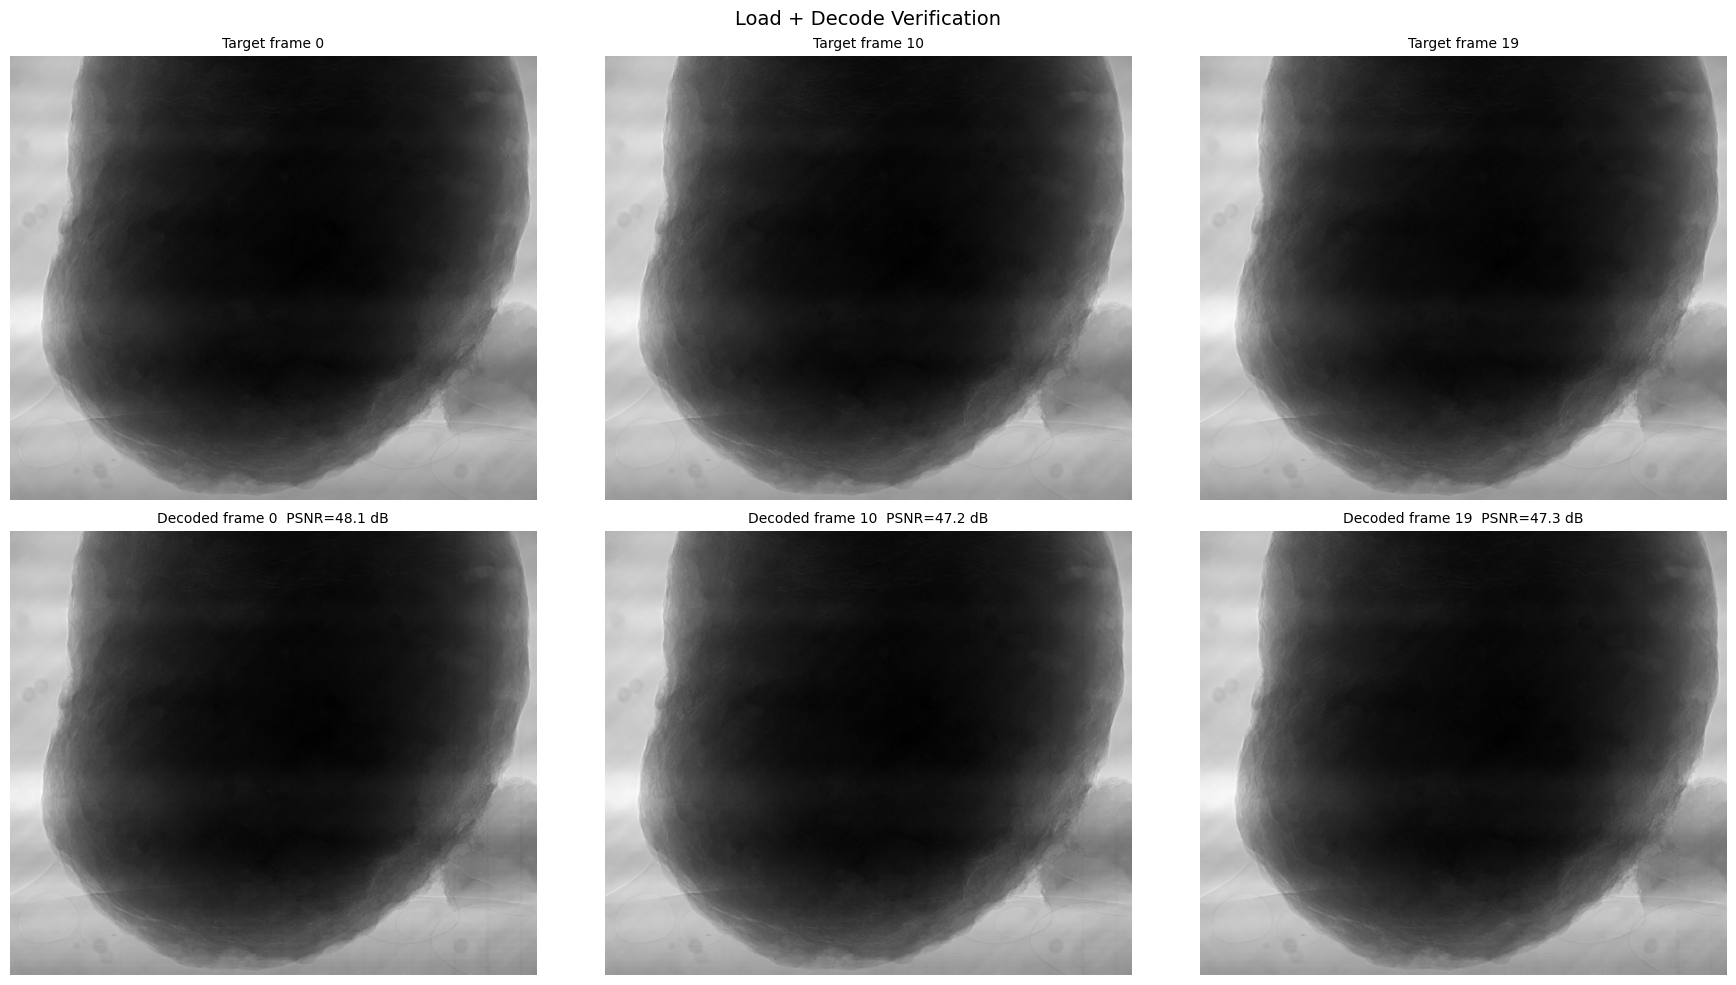

In [12]:
# ── Load the saved sequence and decode ────────────────────────────────────
K_cam, viewmat_cam = ortho_camera(device)
kf_loaded, cfs_loaded, meta_loaded = load_sequence(save_path, device)

decoded_frames = decode_sequence(kf_loaded, cfs_loaded, viewmat_cam, K_cam, W, H)

print(f"Loaded {len(decoded_frames)} frames from {save_path.name}")
print(f"Metadata: {meta_loaded}")

# ── Compare decoded vs original targets ────────────────────────────────────
print(f"\n{'Frame':>6} {'PSNR':>8} {'SSIM':>8}")
print("-" * 25)
for i, (dec, target) in enumerate(zip(decoded_frames, frames)):
    t_np = target.cpu().numpy()
    p = psnr(dec, t_np)
    s = ssim(dec, t_np)
    print(f"{i:>6d} {p:>8.2f} {s:>8.4f}")

# ── Visual check: first, middle, last ─────────────────────────────────────
check_idxs = [0, N_FRAMES // 2, N_FRAMES - 1]
fig, axes = plt.subplots(2, len(check_idxs), figsize=(6 * len(check_idxs), 10))
for j, idx in enumerate(check_idxs):
    t_np = frames[idx].cpu().numpy()
    d_np = decoded_frames[idx]
    axes[0, j].imshow(t_np, cmap='gray', vmin=0, vmax=1)
    axes[0, j].set_title(f'Target frame {idx}', fontsize=10); axes[0, j].axis('off')
    axes[1, j].imshow(d_np, cmap='gray', vmin=0, vmax=1)
    p = psnr(d_np, t_np)
    axes[1, j].set_title(f'Decoded frame {idx}  PSNR={p:.1f} dB', fontsize=10)
    axes[1, j].axis('off')
plt.suptitle('Load + Decode Verification', fontsize=14)
plt.tight_layout()
plt.show()